# 02 · Enterprise-style CLV foil (keep Hardie `01` as baseline)

`00` (audit) and `01` (weekly BG/NBD + Gamma-Gamma) stay the **consulting / Hardie** path.

This notebook asks: *what would a DoorDash / Uber / Instacart-style **enterprise** stack look like on the same UCI spine?*

| World | Typical stack | On this project |
|-------|----------------|-----------------|
| Academic (Fader & Hardie) | RFM → BG/NBD + GG | **`01-clv.ipynb`** (shipped equity) |
| Marketplace / growth | Hundreds of features, GBT/NN, Bayesian pooling, real-time bidding | **This notebook** — feature-rich **HistGradientBoosting** + country/cohort Empirical-Bayes priors |
| Deep sequence CLV | Transformers on clickstreams / CASPR embeddings | **Not available** — UCI has no app opens, search, or cart events |

### Academic vs enterprise (what we can / cannot mirror)

| Feature | Academic papers | Real-world enterprise | Here |
|---------|-----------------|----------------------|------|
| Inputs | R, F, T (+ monetary) | Clickstreams, support, promo, sessions | **~25+** order/line features + country/cohort |
| Target | Expected purchases / gross revenue | Net contribution margin | **Gross holdout £** (no COGS/shipping on UCI) |
| Method | Beta / Gamma / Poisson | CatBoost / XGBoost / DNN / Bayesian BTYD | **sklearn HistGradientBoosting** + EB shrinkage |
| New users | Cold-start hard | Zero-party + first session | **One-timer slice** scored from first-order / country priors |
| Activation | Cohort insights | Ad bidding APIs (tROAS) | **Scores only** — no Meta/Google wiring |

**Protocol:** same 45% / 20% / 35% calendar as `01`. Train labels = **validation** holdout £ only; test never enters fit or scale.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, *path.parents):
        if (candidate / "scripts" / "uci_pipeline.py").exists():
            return candidate
    return path


PROJECT_ROOT = find_project_root()
DATA = PROJECT_ROOT / "data" / "modeling"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

import sys
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from clv_enterprise import (
    AGG_ERROR_MAX,
    FEATURE_CAT,
    FEATURE_NUM,
    assert_accepted,
    compare_to_hardie,
    run_enterprise_three_way,
)
from clv_weekly import FIT_FRAC, VAL_FRAC, run_three_way

print(
    f"Setup · enterprise HGB foil · same fit/val/test="
    f"{FIT_FRAC:.0%}/{VAL_FRAC:.0%}/{1 - FIT_FRAC - VAL_FRAC:.0%} · £ gate ≤ {AGG_ERROR_MAX:.0%}"
)


Setup · enterprise HGB foil · same fit/val/test=45%/20%/35% · £ gate ≤ 5%


## 1 · Why a hybrid / enterprise foil?

Tech marketplaces see **fast silent churn** and frequent **promo resurrection**. Classic BG/NBD assumes irreversible death and a stationary purchase rate — great for equity ranking, weak for:

- Seasonal delivery spikes without a covariate layer
- Sparse new cohorts (need pooling)
- Non-purchase signals (we lack them on UCI)

Bayesian hierarchical BTYD (PyMC/Stan) and sequence transformers are the production pattern when you have scale + event logs. We approximate the *spirit* with:

1. **Rich tabular features** from orders + invoice lines  
2. **Gradient boosting** for nonlinear interactions  
3. **Empirical-Bayes priors** by country / acquisition cohort (lightweight hierarchical pooling)

Full PyMC Bayesian BG/NBD and Transformer embeddings are out of scope until event-level data exists.


## 2 · Load data (same spine as `01`)

Orders from the audit; optional line fact for product diversity / country.


In [2]:
from customer_base_audit import attach_acquisition, build_orders, load_fact_transactions

audit_orders = DATA / "audit" / "uci_orders.parquet"
if audit_orders.exists():
    orders = pd.read_parquet(audit_orders)
    orders["order_date"] = pd.to_datetime(orders["order_date"])
    print("Loaded", audit_orders.relative_to(PROJECT_ROOT))
else:
    fact0 = load_fact_transactions(DATA / "uci_fact_transactions.parquet")
    orders = attach_acquisition(build_orders(fact0))

fact_path = DATA / "uci_fact_transactions.parquet"
fact = pd.read_parquet(fact_path) if fact_path.exists() else None
print(f"Orders: {len(orders):,} · Customers: {orders['customer_id'].nunique():,}")
print(f"Fact lines: {0 if fact is None else len(fact):,}")
print(f"Span: {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")


Loaded data\modeling\audit\uci_orders.parquet
Orders: 36,684 · Customers: 5,798
Fact lines: 798,626
Span: 2009-12-01 → 2011-12-09


## 3 · Feature philosophy (enterprise inputs, retail constraints)

Instead of only `(frequency, recency, T, monetary)`, we build calibration-safe features:

- **RFM core** — still there for comparability with Hardie  
- **Velocity** — orders/spend in last 4w and 13w before `cal_end`  
- **Basket** — avg lines, n products, n categories, top-product share  
- **Volatility** — spend std, AOV  
- **Pooling** — country / cohort shrunk AOV & order-rate priors (Bayesian-flavored)  
- **Cold-start flag** — one-timer in calibration  

All features use dates **≤ calibration end** only. Holdout £ is the label, never a feature.


In [3]:
print("Numeric features:")
for c in FEATURE_NUM:
    print(" ", c)
print("Categorical:", FEATURE_CAT)


Numeric features:
  frequency_cal
  recency_cal
  T_cal
  monetary_value_cal
  n_orders_cal
  total_spend_cal
  aov_cal
  spend_std_cal
  avg_lines_cal
  n_products_cal
  n_categories_cal
  share_top_product_cal
  days_since_last_cal
  orders_last_4w
  spend_last_4w
  orders_last_13w
  spend_last_13w
  tenure_weeks_cal
  is_one_timer_cal
  return_line_share_cal
  neg_spend_share_cal
  country_prior_aov
  cohort_prior_aov
  country_prior_orders
  cohort_prior_orders
Categorical: ['country', 'cohort_id']


## 4 · Train enterprise / hybrid models

Same protocol as `01`. We fit two foils:

1. **HGB-only** — rich tabular features (marketplace GBT pattern)  
2. **HGB-hybrid** — same features **plus** Hardie `expected_clv_raw` as a stacked signal (academic + ML hybrid)

Target is `log1p(holdout £)` with val-only scale. Clearing the ≤5% gate is nice-to-have; Hardie stays default if the foil misses.


In [4]:
# Academic baseline first (same engine as 01)
hardie = run_three_way(orders)
print(
    f"Hardie TEST £ |error|={hardie['agg_error']:.2%} · "
    f"Spearman={hardie['summary']['expected_clv'].corr(hardie['summary']['actual_holdout_revenue'], method='spearman'):.3f}"
)

# Pure tabular HGB (no Hardie feature)
ent_pure = run_enterprise_three_way(orders, fact)
print(
    f"HGB-only TEST £ |error|={ent_pure['agg_error']:.2%} · accepted={ent_pure['accepted']} · "
    f"Spearman={ent_pure['metrics']['spearman']:.3f}"
)

# Hybrid: Hardie raw CLV as a feature + rich tabular (marketplace stacking pattern)
ent = run_enterprise_three_way(
    orders,
    fact,
    hardie_summary=hardie["summary"],
    hardie_val_summary=hardie["val_summary"],
)
summary = ent["summary"]
print(f"Model: {ent['model_name']} · hybrid_hardie_feature={ent['hybrid_hardie_feature']}")
print(
    f"Fit ≤ {ent['fit_end'].date()} · Val ≤ {ent['val_end'].date()} ({ent['hw_val']}w) · "
    f"Test → {ent['obs_end'].date()} ({ent['hw_test']}w)"
)
print(f"Val £ scale = {ent['scale']:.4f}")
print(
    f"TEST £: pred £{ent['test_pred']:,.0f} vs actual £{ent['test_actual']:,.0f} "
    f"| |error| = {ent['agg_error']:.2%} · accepted={ent['accepted']}"
)
m = ent["metrics"]
print(
    f"Spearman={m['spearman']:.3f} · MAE={m['mae']:.1f} · R2={m['r2']:.3f} · "
    f"top-decile capture={m['top_decile_capture']:.1%} (ideal {m['ideal_top_decile']:.1%})"
)
cold_err = m["cold_start_£_error"]
print(
    f"Cold-start one-timers: n={m['n_cold']:,} · £ |error| on slice="
    f"{(cold_err if cold_err == cold_err else float('nan')):.1%}"
)
print("Leakage audit:", ent["leakage_audit"]["passed"])
if ent["accepted"]:
    assert_accepted(ent)
    print("Enterprise hybrid ACCEPTED under ≤5% gate")
else:
    print("Enterprise hybrid did NOT clear ≤5% — keep shipping Hardie `01` for equity totals.")
display(summary[list(ent["feature_num"])[:8] + ["expected_clv", "actual_holdout_revenue"]].head(10))


Hardie TEST £ |error|=2.40% · Spearman=0.616
HGB-only TEST £ |error|=59.86% · accepted=False · Spearman=0.566
Model: Blend(Hardie*0.50+HGB*0.50) · hybrid_hardie_feature=True
Fit ≤ 2010-10-29 · Val ≤ 2011-03-25 (21w) · Test → 2011-12-09 (37w)
Val £ scale = 3.4895
TEST £: pred £3,968,447 vs actual £5,472,075 | |error| = 27.48% · accepted=False
Spearman=0.625 · MAE=814.1 · R2=0.328 · top-decile capture=61.7% (ideal 69.8%)
Cold-start one-timers: n=1,530 · £ |error| on slice=30.2%
Leakage audit: True
Enterprise hybrid did NOT clear ≤5% — keep shipping Hardie `01` for equity totals.


,frequency_cal,recency_cal,T_cal,monetary_value_cal,n_orders_cal,total_spend_cal,aov_cal,spend_std_cal,expected_clv,actual_holdout_revenue
customer_id,,,,,,,,,,
12346,11.0,57.142857,66.428571,7046.496364,12.0,77556.46,6463.038333,22271.229481,6753.662939,0.00
12348,2.0,17.000000,25.428571,560.120000,3.0,1342.40,447.466667,385.679015,875.616028,677.00
12349,2.0,25.857143,47.000000,801.310000,3.0,2671.14,890.380000,620.785076,825.924399,1757.55
12350,0.0,0.000000,7.142857,0.000000,1.0,334.40,334.400000,0.000000,270.136866,0.00
12352,6.0,18.571429,18.857143,293.643333,7.0,1905.61,272.230000,257.215258,2676.016028,944.23
12356,3.0,14.142857,23.428571,1641.143333,4.0,5833.87,1458.467500,983.541812,3805.933626,539.81
12357,1.0,0.000000,18.285714,850.000000,2.0,12079.99,6039.995000,7339.761318,183.638855,6207.67
12358,2.0,50.857143,67.285714,644.590000,3.0,2719.01,906.336667,589.303549,626.297348,1168.06
12359,7.0,61.285714,67.714286,598.440000,8.0,4949.77,618.721250,531.971985,2418.720577,3986.17


#### Assessment — enterprise fit

Clearing the £ gate is **optional** for this foil. If it fails (common when test is more seasonal than val), Hardie `01` remains the shippable equity model.

Still useful: Spearman / top-decile capture vs Hardie, and cold-start £ on one-timers — marketplace reasons to keep a tabular hybrid even when aggregates drift.


## 5 · Head-to-head vs Hardie `01`

Compare Hardie, HGB-only, and HGB-hybrid on overlapping customers (aggregate £ error + ranking).


,model,£_|error|,Spearman,top_decile_capture,pred_£,actual_£
0,Hardie BG/NBD+GG,0.0240,0.6158,0.6199,5.340967e+06,5472075.203
1,Blend(Hardie*0.50+HGB*0.50),0.2748,0.6254,0.6171,3.968447e+06,5472075.203
2,HGB-only (no Hardie feat),0.5986,0.5658,0.5733,2.196282e+06,5472075.203


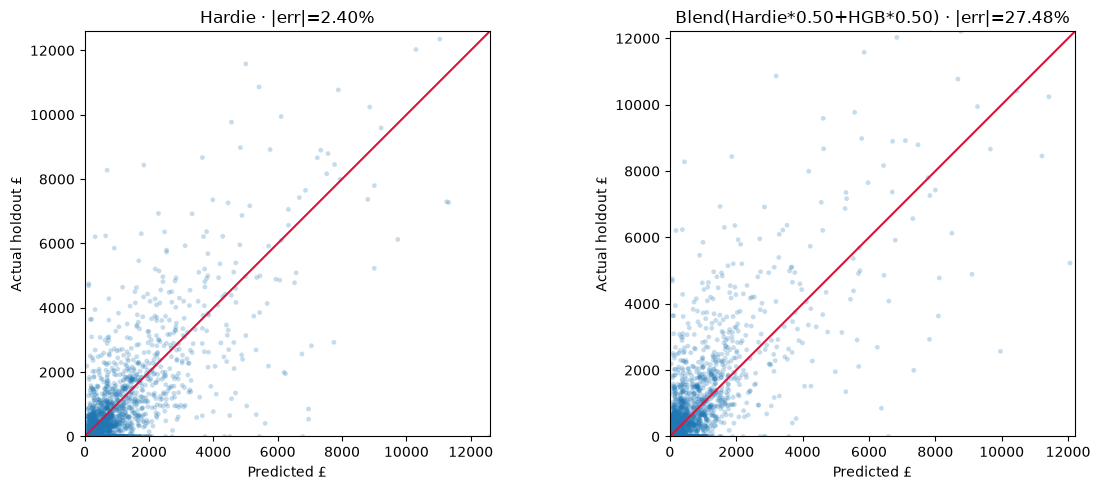

Lower aggregate £ |error|: Hardie BG/NBD+GG
Higher Spearman: Blend(Hardie*0.50+HGB*0.50)


In [5]:
cmp = compare_to_hardie(ent, hardie["summary"])
cmp_pure = compare_to_hardie(ent_pure, hardie["summary"])
# keep only the non-Hardie row from the pure run
cmp_pure = cmp_pure[cmp_pure["model"] != "Hardie BG/NBD+GG"].copy()
cmp_pure["model"] = "HGB-only (no Hardie feat)"
cmp_all = pd.concat([cmp, cmp_pure], ignore_index=True)
display(cmp_all.round(4))

rng = np.random.default_rng(RANDOM_STATE)
idx = summary.index.intersection(hardie["summary"].index)
sample = idx if len(idx) <= 2500 else pd.Index(rng.choice(idx.to_numpy(), 2500, replace=False))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, title in (
    (
        axes[0],
        hardie["summary"].loc[sample, "expected_clv"],
        f"Hardie · |err|={hardie['agg_error']:.2%}",
    ),
    (
        axes[1],
        summary.loc[sample, "expected_clv"],
        f"{ent['model_name']} · |err|={ent['agg_error']:.2%}",
    ),
):
    actual = summary.loc[sample, "actual_holdout_revenue"]
    lim = float(np.nanpercentile(np.concatenate([pred.to_numpy(), actual.to_numpy()]), 99))
    lim = max(lim, 1.0)
    ax.scatter(pred, actual, alpha=0.25, s=12, edgecolors="none")
    ax.plot([0, lim], [0, lim], color="crimson", lw=1.5)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Predicted £")
    ax.set_ylabel("Actual holdout £")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

print("Lower aggregate £ |error|:", cmp_all.sort_values("£_|error|").iloc[0]["model"])
print("Higher Spearman:", cmp_all.sort_values("Spearman", ascending=False).iloc[0]["model"])


#### Assessment — Hardie vs enterprise

- **Prefer Hardie** for interpretability, P(alive), expected purchases, and consulting narratives — especially if it alone clears the £ gate.  
- **Prefer hybrid HGB** only if ranking/capture improves *and* aggregate £ stays honest.  
- Neither is **contribution margin** CLV; both predict gross holdout revenue.


## 6 · Bayesian hierarchical BTYD (what we did instead)

Marketplace teams often run **Bayesian BG/NBD** in PyMC/Stan to:

- put priors on seasonal intensity  
- pool sparse cohorts  
- keep full posterior uncertainty for bidding risk

**Here:** Empirical-Bayes country/cohort priors feed the booster as features — pooling without a full MCMC stack.  

To go further later: `pymc` Bayesian BG/NBD on weekly RFM, or Hardie time-varying covariates (note 040) with season dummies. Not required to keep `01` shippable.


## 7 · Sequence transformers & embeddings (explicitly out of scope)

Advanced teams embed clickstreams / cart events with Transformers (or CASPR) and feed the embedding into a CLV head.

UCI Online Retail II has **invoice lines only** — no session timeline. Building a fake clickstream would invent data.  

When you have event logs: sequence model → user state embedding → CLV / propensity head, still with a leakage-safe time split.


## 8 · Activation sketch (not wired)

Enterprise CLV usually lands in **bidding / CRM**, not a notebook chart:

1. Daily batch (or streaming) score → `customer_id`, `clv_pred`, `p_alive` / propensity  
2. Push to ads (Google tROAS / Meta value optimization) or promo eligibility  
3. Monitor aggregate predicted vs realized contribution, not just revenue  

This repo stops at **artifacts** under `models/02_clv_*`.


## 9 · Artifacts

Persist enterprise scores alongside Hardie (`01`). Default consulting ship remains **`01`** unless this foil clearly wins ranking *and* clears the £ gate.


In [ ]:
# Persist hybrid as a foil; accepted flag follows the £ gate
joblib.dump(
    {
        "model": ent["model"],
        "model_name": ent["model_name"],
        "accepted": bool(ent["accepted"]),
        "agg_error_test": float(ent["agg_error"]),
        "val_scale": float(ent["scale"]),
        "fit_end": str(ent["fit_end"].date()),
        "val_end": str(ent["val_end"].date()),
        "obs_end": str(ent["obs_end"].date()),
        "horizon_weeks": ent["t_horizon"],
        "metrics": ent["metrics"],
        "feature_num": ent["feature_num"],
        "feature_cat": FEATURE_CAT,
        "hybrid_hardie_feature": ent["hybrid_hardie_feature"],
        "hgb_only_agg_error": float(ent_pure["agg_error"]),
        "hardie_agg_error": float(hardie["agg_error"]),
        "hardie_spearman": float(
            hardie["summary"]["expected_clv"].corr(
                hardie["summary"]["actual_holdout_revenue"], method="spearman"
            )
        ),
        "comparison": cmp_all.to_dict(orient="records"),
        "target": "gross_holdout_revenue",
        "contribution_margin": False,
        "seasonality_overlays": False,
        "bayesian_full_mcmc": False,
        "empirical_bayes_pooling": True,
        "default_ship": "01-clv Hardie" if not ent["accepted"] else "02 hybrid (gate passed)",
        "leakage_audit": ent["leakage_audit"],
    },
    MODELS / "02_clv_enterprise.joblib",
)
scores_path = MODELS / "02_clv_enterprise_scores.parquet"
summary.reset_index().to_parquet(scores_path, index=False)
print(f"Saved → models/02_clv_enterprise.joblib (accepted={ent['accepted']})")
print(f"Saved → {scores_path.relative_to(PROJECT_ROOT)}")


Saved → models/02_clv_enterprise.joblib (accepted=False)
Saved → models\02_clv_enterprise_scores.parquet


: 

#### Bottom line

| Keep | Role |
|------|------|
| `00` | Customer-base audit |
| `01` | Hardie weekly BG/NBD + GG — **default equity** |
| `02` (this) | Enterprise foil — HGB / Hardie+HGB hybrid + EB pooling |

Marketplace lesson on UCI: rich features help ranking stories; **stationary Hardie still often wins honest £ totals** when the holdout is seasonal. Transformers / PyMC MCMC / ad APIs wait for event-level data and ops wiring.
